<a href="https://colab.research.google.com/github/sandomin94/coding_dojo_cores/blob/dev/proyecto1_parte4_core.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importar librerías

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importar dataframe y analizar estructura de datos

In [6]:
df = pd.read_csv('/content/retail_sales_dataset.csv')
print(df.head())

##Imprime ultimas 5 filas
print("nÚltimas 5 filas del DataFrame:")
print(df.tail(5))
##Imprime informacion del dataframe
print("nInformación del DataFrame:")
print(df.info())
## Imprime estadistica descriptiva del DF
print("nEstadísticas descriptivas del DataFrame:")
print(df.describe())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  
nÚltimas 5 filas del DataFrame:
     Transaction ID        Date Customer ID  Gender  Age Product Category  \
995             996  2023-05-16     CUST996    Male   62         Clothing   
996             997  2023-11-17     CUST997    Male   52           Beauty   
997             998  2

Limpieza del df

In [7]:
##Verificacion de elementos duplicados
print("Cantidad de filas duplicadas antes de la eliminacion: ",df.duplicated().sum())
##Verificacion y ajustes de tipos de datos
print("Dtype Original: ", df.dtypes)

# Definir el diccionario de tipos de datos (excluyendo las fechas)
diccionario = {
    'Transaction ID': 'int64',
    'Date': 'date',
    'Customer ID': 'string',
    'Gender': 'string',
    'Age': 'int64',
    'Product Category': 'string',
    'Quantity': 'int64',
    'Price per Unit': 'int64',
    'Total Amount': 'int64'
}

# Función para mapear tipos personalizados a tipos de pandas
def map_tipo(tipo_personalizado):
    mapping = {
        'string': 'string',
        'int64':'int64',
        'float64': 'float64',
        'date': 'datetime64[ns]'
    }
    return mapping.get(tipo_personalizado, 'object')  # 'object' como valor por defecto

# Crear un nuevo diccionario mapeado para pandas
diccionario_mapeado = {col: map_tipo(tipo) for col, tipo in diccionario.items()}## itera entre los elementos del diccionario y mapea

print("Diccionario Mapeado para pandas:")
print(diccionario_mapeado)

Cantidad de filas duplicadas antes de la eliminacion:  0
Dtype Original:  Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object
Diccionario Mapeado para pandas:
{'Transaction ID': 'int64', 'Date': 'datetime64[ns]', 'Customer ID': 'string', 'Gender': 'string', 'Age': 'int64', 'Product Category': 'string', 'Quantity': 'int64', 'Price per Unit': 'int64', 'Total Amount': 'int64'}


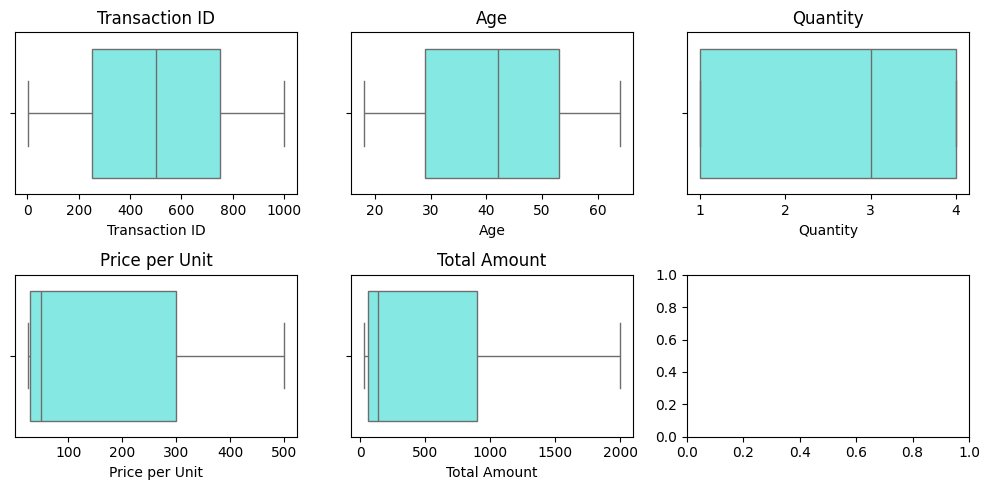

In [8]:
## Ploteado de datos anomalos para verificacion de outliers
## Se toman en consideracion las columnas numericas
features_numericos = ['Transaction ID','Age', 'Quantity', 'Price per Unit', 'Total Amount']

def plot_grafico_outliers(features, df):

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 5))

    for i, feature in enumerate(features):
        row, col = divmod(i, 3)
        sns.boxplot(x=df[feature], ax=axes[row, col], color="#75f8f2")
        axes[row, col].set_title(feature)

    plt.tight_layout()
    plt.show()
plot_grafico_outliers(features_numericos,df)

Análisis descriptivo y Visualización

In [9]:
print('Estadistica descriptiva del dataset')
print(df.describe())

Estadistica descriptiva del dataset
       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000


Histogramas y Boxplots para variables numericas clave

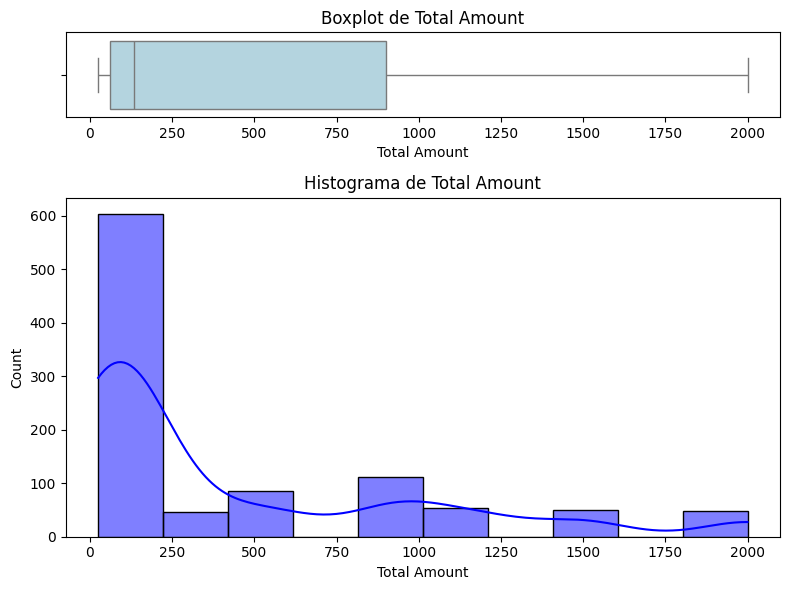

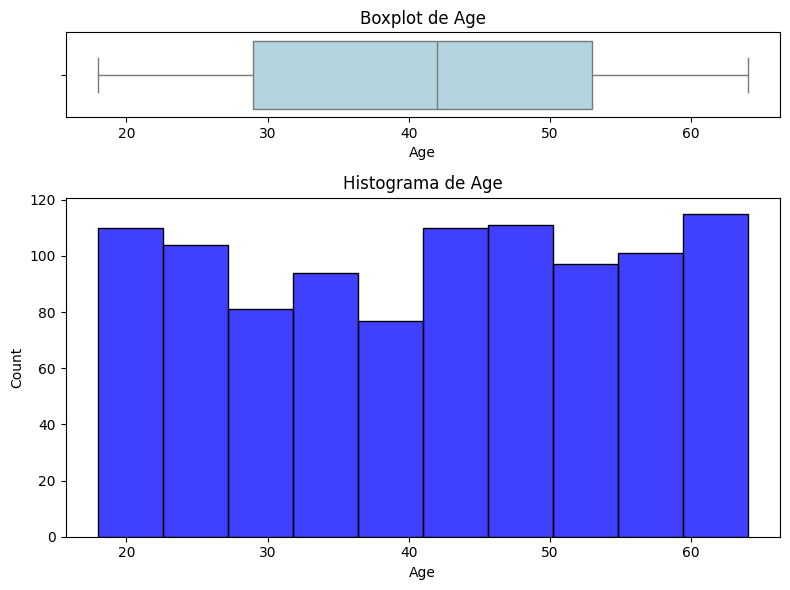

In [10]:
# Crear una figura con subplots 1
fig, ax = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [1, 4]})

# Crear el boxplot en el subplot superior
sns.boxplot(x=df['Total Amount'], ax=ax[0], color='lightblue')
ax[0].set_title('Boxplot de Total Amount')

# Crear el histograma en el subplot inferior
sns.histplot(df['Total Amount'], bins=10, kde=True, ax=ax[1], color='blue')
ax[1].set_title('Histograma de Total Amount')

# Ajustar el layout para evitar solapamiento
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# Crear una figura con subplots 2
fig, ax = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [1, 4]})

# Crear el boxplot en el subplot superior
sns.boxplot(x=df['Age'], ax=ax[0], color='lightblue')
ax[0].set_title('Boxplot de Age')

# Crear el histograma en el subplot inferior
sns.histplot(df['Age'], bins=10, kde=False, ax=ax[1], color='blue')
ax[1].set_title('Histograma de Age')

# Ajustar el layout para evitar solapamiento
plt.tight_layout()

# Mostrar el gráfico
plt.show()

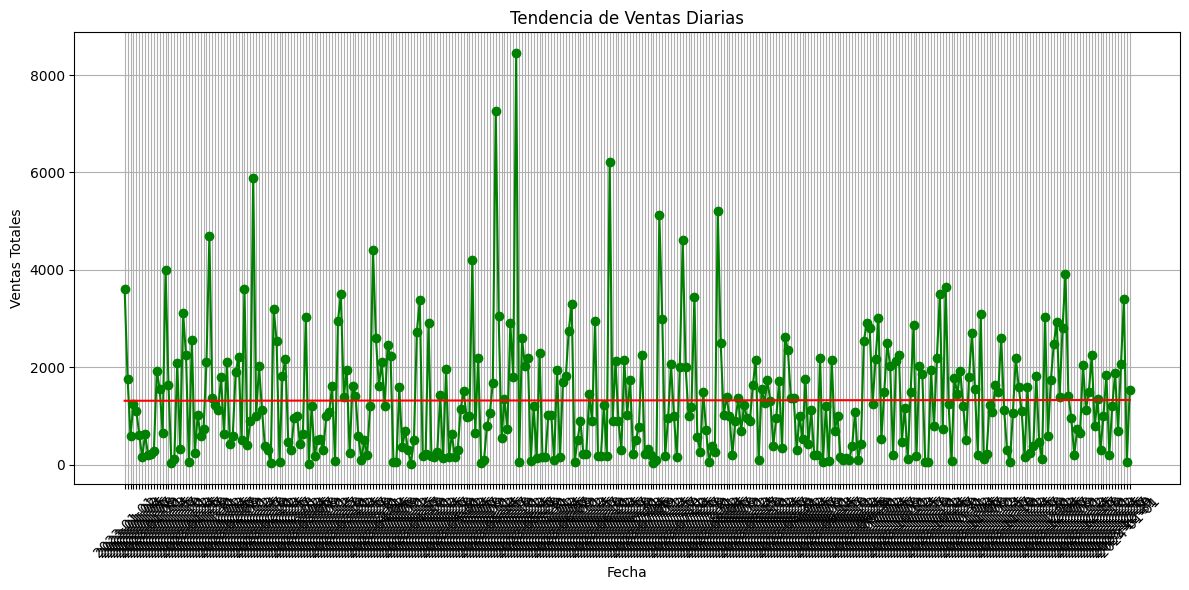

In [12]:
###Crea gráficos de líneas para mostrar las tendencias de ventas a lo largo del tiempo.

ventas_diarias = df.groupby('Date')['Total Amount'].sum()
# Calcular la línea de tendencia
x = np.arange(len(ventas_diarias))  # Crear un array de índices
y = ventas_diarias.values  # Valores de ventas
m, b = np.polyfit(x, y, 1)  # Ajuste de mínimos cuadrados (pendiente y ordenada al origen)

##Crear el gráfico
plt.figure(figsize=(12, 6))
plt.plot(ventas_diarias.index, ventas_diarias, marker='o', linestyle='-', color='green')
plt.plot(ventas_diarias.index, m * x + b, color='red', label='Línea de Tendencia')  # Agregar línea de tendencia
plt.title('Tendencia de Ventas Diarias')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

#Obs: Las ventas se mantienen constante a través del tiempo

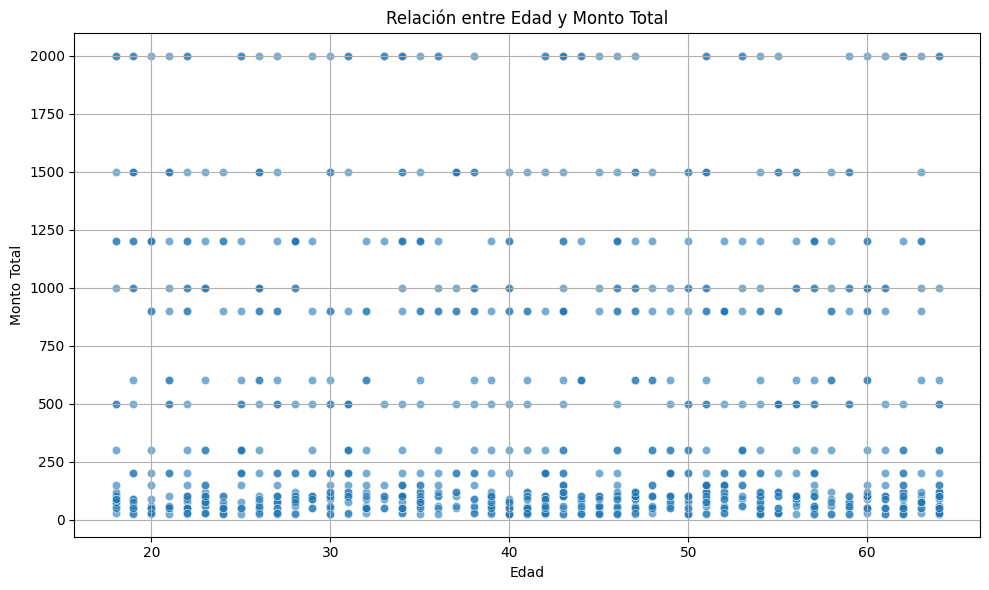

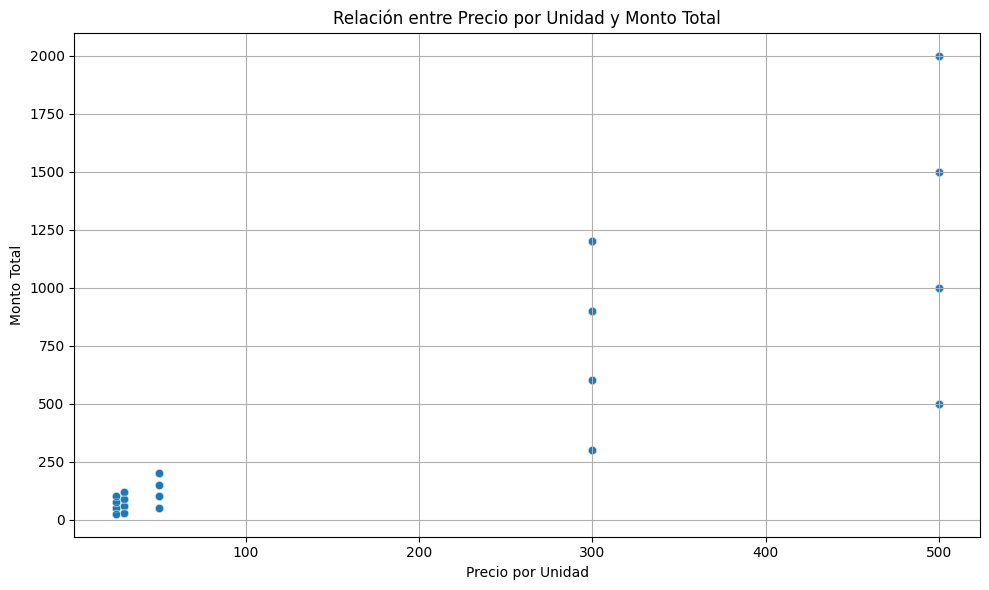

In [14]:
### Utiliza gráficos de dispersión para analizar la relación entre diferentes variables
# Crear un gráfico de dispersión entre Age y Total Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Total Amount', data=df, alpha=0.6)
plt.title('Relación entre Edad y Monto Total')
plt.xlabel('Edad')
plt.ylabel('Monto Total')
plt.grid()
plt.tight_layout()
plt.show()

#Obs: no hay relacion entre edad y monto total

# Crear un gráfico de dispersión entre Price per unit y Total Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Price per Unit', y='Total Amount', data=df, alpha=0.6)
plt.title('Relación entre Precio por Unidad y Monto Total')
plt.xlabel('Precio por Unidad')
plt.ylabel('Monto Total')
plt.grid()
plt.tight_layout()
plt.show()

#Obs: existe un relación entre precio por unidad y monto total. Es decir, a mayor precio, mayor monto total. Sin embargo, existen el gráfico muestra que existe una gran cantidad de montos pequeños (precio por unidad bajo y venta baja)

